In [1]:
import sys, pandas, numpy, sklearn, matplotlib
print("Python:", sys.version)
print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("All good ✅")


Python: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]
pandas: 2.3.3
scikit-learn: 1.9.0
All good ✅


In [3]:
# Step 1 : Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Step 2 : Load Dataset

df = pd.read_csv(r"D:\MLOps\Project\Dataset\student-por.csv", sep=";")

# Step 3 : Display Dataset Information

print("First Five Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nMissing Values")
print(df.isnull().sum())

# Step 4 : Define Target Column

target = "G3"

X = df.drop(columns=[target])

y = df[target]

# Step 5 : Identify Numerical and Categorical Columns

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = X.select_dtypes(include=["object"]).columns

# Step 6 : Numerical Pipeline

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Step 7 : Categorical Pipeline

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Step 8 : Combine Pipelines

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

# Step 9 : Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Step 10 : Apply Preprocessing

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("\nTraining Data Shape")
print(X_train_processed.shape)

print("\nTesting Data Shape")
print(X_test_processed.shape)

# Step 11 : Save Processed Dataset

processed_data = preprocessor.fit_transform(X)

processed_df = pd.DataFrame(
    processed_data.toarray() if hasattr(processed_data, "toarray") else processed_data
)

processed_df["G3"] = y.values

processed_df.to_csv("processed_student_data.csv", index=False)

print("\nProcessed dataset saved successfully.")

First Five Rows
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]

Shape of Dataset
(649, 33)

Column Names
Index(['school', 'sex', 'age',

In [5]:
# ============================================================
# Student Data Preprocessing Pipeline
# ============================================================

# Step 1 : Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Step 2 : Load Dataset

df = pd.read_csv(r"D:\MLOps\Project\Dataset\student-por.csv", sep=";")

# Step 3 : Display Dataset Information

print("First Five Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nMissing Values")
print(df.isnull().sum())

# Step 4 : Define Features and Target

target = "G3"

X = df.drop(columns=[target])
y = df[target]

# Step 5 : Identify Numerical and Categorical Columns

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

# Step 6 : Numerical Pipeline

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Step 7 : Categorical Pipeline

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Step 8 : Combine Pipelines

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

# Step 9 : Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Step 10 : Fit Preprocessor on Training Data

preprocessor.fit(X_train)

# Transform Training and Testing Data

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nTraining Data Shape")
print(X_train_processed.shape)

print("\nTesting Data Shape")
print(X_test_processed.shape)

# Step 11 : Transform Entire Dataset (without refitting)

processed_data = preprocessor.transform(X)

# Convert Sparse Matrix to DataFrame

if hasattr(processed_data, "toarray"):
    processed_data = processed_data.toarray()

processed_df = pd.DataFrame(processed_data)

# Add Target Column

processed_df["G3"] = y.values

# Save Processed Dataset

processed_df.to_csv("processed_student_data.csv", index=False)

print("\nProcessed dataset saved successfully.")
print("File Name : processed_student_data.csv")

print("\nProcessed Dataset Shape")
print(processed_df.shape)

First Five Rows
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]

Shape of Dataset
(649, 33)

Column Names
['school', 'sex', 'age', 'addr

In [7]:
# Step 1 : Import Libraries

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Step 2 : Load Dataset

df = pd.read_csv(r"D:\MLOps\Project\Dataset\student-por.csv", sep=";")

# Step 3 : Feature Engineering

df["Average_Grade"] = (df["G1"] + df["G2"]) / 2

df["Study_Efficiency"] = df["studytime"] / (df["absences"] + 1)

df["Parent_Education"] = (df["Medu"] + df["Fedu"]) / 2

df["Student_Wellbeing"] = (
    df["famrel"] +
    df["freetime"] +
    df["health"]
) / 3

# Step 4 : Save Feature Store

feature_store = df[
    [
        "Average_Grade",
        "Study_Efficiency",
        "Parent_Education",
        "Student_Wellbeing"
    ]
]

feature_store.to_csv("engineered_features.csv", index=False)

print("Feature Store Created Successfully")

# Step 5 : Define Target

target = "G3"

# Original Dataset

X_original = df.drop(
    columns=[
        "G3",
        "Average_Grade",
        "Study_Efficiency",
        "Parent_Education",
        "Student_Wellbeing"
    ]
)

# Engineered Dataset

X_engineered = df.drop(columns=["G3"])

y = df[target]

# Function to train and evaluate

def train_model(X, y):

    numerical_columns = X.select_dtypes(
        include=["int64", "float64"]
    ).columns

    categorical_columns = X.select_dtypes(
        include=["object"]
    ).columns

    preprocessor = ColumnTransformer(
        [
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="mean"))
                ]),
                numerical_columns
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_columns
            )
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    X_train = preprocessor.fit_transform(X_train)
    X_test = preprocessor.transform(X_test)

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    score = r2_score(y_test, predictions)

    return score

# Step 6 : Compare Results

score_original = train_model(X_original, y)

score_engineered = train_model(X_engineered, y)

print("\nR² Score Without Feature Engineering :", round(score_original, 3))

print("R² Score With Feature Engineering :", round(score_engineered, 3))

# Step 7 : Load Feature Store

stored_features = pd.read_csv("engineered_features.csv")

print("\nStored Features")

print(stored_features.head())

Feature Store Created Successfully

R² Score Without Feature Engineering : 0.839
R² Score With Feature Engineering : 0.819

Stored Features
   Average_Grade  Study_Efficiency  Parent_Education  Student_Wellbeing
0            5.5          0.400000               4.0           3.333333
1           10.0          0.666667               1.0           3.666667
2           12.5          0.285714               1.0           3.333333
3           14.0          3.000000               3.0           3.333333
4           12.0          2.000000               3.0           4.000000


In [10]:
# ===============================
# EXPERIMENT 4
# Model Management & Registry
# ===============================

import os
import joblib
import pandas as pd

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

# -------------------------------
# Create Model Folder
# -------------------------------

os.makedirs("models", exist_ok=True)

# -------------------------------
# Load Processed Dataset
# -------------------------------

df = pd.read_csv("processed_student_data.csv")

# -------------------------------
# Define Target
# -------------------------------

target = "G3"

X = df.drop(columns=[target])

y = df[target]

# -------------------------------
# Train Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# -------------------------------
# Model 1
# Linear Regression
# -------------------------------

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)

lr_mae = mean_absolute_error(y_test, lr_pred)

# -------------------------------
# Save Model
# -------------------------------

joblib.dump(
    lr,
    "models/linear_regression.pkl"
)

# -------------------------------
# Model 2
# Random Forest
# -------------------------------

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)

joblib.dump(
    rf,
    "models/random_forest.pkl"
)

# -------------------------------
# Create Model Registry
# -------------------------------

registry = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "Version":[
        "1.0",
        "1.0"
    ],

    "R2 Score":[
        lr_r2,
        rf_r2
    ],

    "MAE":[
        lr_mae,
        rf_mae
    ],

    "Date":[
        datetime.now(),
        datetime.now()
    ]
})

best_model = registry.loc[
    registry["R2 Score"].idxmax(),
    "Model"
]

registry["Status"] = registry["Model"].apply(

    lambda x:
    "Production"
    if x == best_model
    else "Staging"

)

registry.to_csv(
    "model_registry.csv",
    index=False
)

# -------------------------------
# Load Best Model
# -------------------------------

if best_model == "Random Forest":

    model = joblib.load(
        "models/random_forest.pkl"
    )

else:

    model = joblib.load(
        "models/linear_regression.pkl"
    )

# -------------------------------
# Predict First Student
# -------------------------------

prediction = model.predict(
    X_test.iloc[[0]]
)

print("Linear Regression")
print("R² Score :", round(lr_r2,3))
print("MAE :", round(lr_mae,3))

print()

print("Random Forest")
print("R² Score :", round(rf_r2,3))
print("MAE :", round(rf_mae,3))

print("\nPrediction for First Test Student")

print(round(prediction[0],2))

print("\nActual G3")

print(y_test.iloc[0])

print("\nBest Model")

print(best_model)

print("\nModel Registry Created Successfully")

Linear Regression
R² Score : 0.849
MAE : 0.765

Random Forest
R² Score : 0.839
MAE : 0.754

Prediction for First Test Student
18.4

Actual G3
19

Best Model
Linear Regression

Model Registry Created Successfully


Baseline R² Score : 0.839

Best Parameters
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Tuned Model R² Score : 0.848

Tuned Model Saved Successfully

Comparison Table
      Model  R2 Score
0  Baseline  0.839288
1     Tuned  0.848050


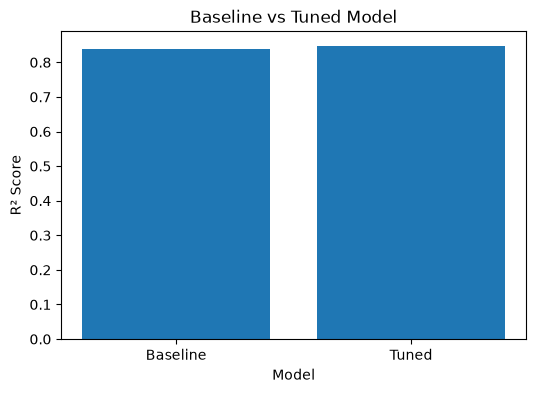

In [11]:
# ====================================
# EXPERIMENT 5
# Hyperparameter Tuning
# ====================================

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# -----------------------------
# Load Dataset
# -----------------------------

df = pd.read_csv("processed_student_data.csv")

target = "G3"

X = df.drop(columns=[target])
y = df[target]

# -----------------------------
# Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# -----------------------------
# Baseline Model
# -----------------------------

baseline_model = RandomForestRegressor(random_state=42)

baseline_model.fit(X_train, y_train)

baseline_prediction = baseline_model.predict(X_test)

baseline_score = r2_score(y_test, baseline_prediction)

print("Baseline R² Score :", round(baseline_score,3))

# -----------------------------
# Hyperparameter Grid
# -----------------------------

param_grid = {

    "n_estimators":[50,100,150],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5,10]

}

# -----------------------------
# Grid Search
# -----------------------------

grid_search = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid_search.fit(X_train,y_train)

print("\nBest Parameters")

print(grid_search.best_params_)

# -----------------------------
# Best Model
# -----------------------------

best_model = grid_search.best_estimator_

prediction = best_model.predict(X_test)

tuned_score = r2_score(y_test,prediction)

print("\nTuned Model R² Score :", round(tuned_score,3))

# -----------------------------
# Save Tuned Model
# -----------------------------

joblib.dump(best_model,"models/tuned_random_forest.pkl")

print("\nTuned Model Saved Successfully")

# -----------------------------
# Comparison Table
# -----------------------------

comparison = pd.DataFrame({

    "Model":[
        "Baseline",
        "Tuned"
    ],

    "R2 Score":[
        baseline_score,
        tuned_score
    ]

})

print("\nComparison Table")

print(comparison)

# -----------------------------
# Visualization
# -----------------------------

plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.title("Baseline vs Tuned Model")

plt.xlabel("Model")

plt.ylabel("R² Score")

plt.show()

In [12]:
# ======================================
# EXPERIMENT 6
# Model Deployment Preparation
# ======================================

import os
import joblib
import pandas as pd
from datetime import datetime
from sklearn.metrics import r2_score

# -----------------------------------
# Create Deployment Folder
# -----------------------------------

os.makedirs("deployment", exist_ok=True)

# -----------------------------------
# Load Processed Dataset
# -----------------------------------

df = pd.read_csv("processed_student_data.csv")

target = "G3"

X = df.drop(columns=[target])

y = df[target]

# -----------------------------------
# Load Tuned Model
# -----------------------------------

model = joblib.load("models/tuned_random_forest.pkl")

print("Tuned Model Loaded Successfully")

# -----------------------------------
# Test Prediction
# -----------------------------------

prediction = model.predict(X.iloc[[0]])

print("\nPrediction for First Student")

print(round(prediction[0],2))

print("\nActual G3")

print(y.iloc[0])

# -----------------------------------
# Evaluate Model
# -----------------------------------

predictions = model.predict(X)

score = r2_score(y, predictions)

print("\nOverall R² Score")

print(round(score,3))

# -----------------------------------
# Save Deployment Model
# -----------------------------------

joblib.dump(
    model,
    "deployment/deployment_model.pkl"
)

print("\nDeployment Model Saved Successfully")

# -----------------------------------
# Create Deployment Information
# -----------------------------------

with open("deployment/deployment_info.txt","w") as file:

    file.write("MODEL DEPLOYMENT INFORMATION\n\n")

    file.write("Model Name : Tuned Random Forest\n")

    file.write("Algorithm : Random Forest Regressor\n")

    file.write("Version : 1.0\n")

    file.write("Dataset : Student Performance Dataset\n")

    file.write("Target : G3\n")

    file.write(f"R2 Score : {round(score,3)}\n")

    file.write(f"Created On : {datetime.now()}\n")

print("Deployment Information File Created")

# -----------------------------------
# Check Deployment Files
# -----------------------------------

print("\nDeployment Folder Files")

print(os.listdir("deployment"))

Tuned Model Loaded Successfully

Prediction for First Student
10.72

Actual G3
11

Overall R² Score
0.913

Deployment Model Saved Successfully
Deployment Information File Created

Deployment Folder Files
['deployment_info.txt', 'deployment_model.pkl']


In [ ]:
# ======================================
# EXPERIMENT 9
# Batch Prediction System
# ======================================

import pandas as pd
import joblib

# -----------------------------
# Load Processed Dataset
# -----------------------------

df = pd.read_csv(r"D:\MLOps\processed_student_data.csv")

# -----------------------------
# Separate Features and Target
# -----------------------------
# Separate Features and Target
X = df.drop(columns=["G3"])

# Convert categorical columns into one-hot encoded columns
X = pd.get_dummies(X)

# Load model
model = joblib.load("deployment/deployment_model.pkl")

# Match feature names used during training
model_features = model.feature_names_in_

# Add missing columns with value 0
for col in model_features:
    if col not in X.columns:
        X[col] = 0

# Remove extra columns and keep the same order
X = X[model_features]

# Predict
predictions = model.predict(X)

# -----------------------------
# Store Predictions
# -----------------------------

df["Predicted_G3"] = predictions.round(2)

# -----------------------------
# Save CSV File
# -----------------------------

df.to_csv("batch_predictions.csv", index=False)

print("\nBatch Prediction Completed Successfully")

print("\nFirst Five Predictions")

print(df[["G3", "Predicted_G3"]].head())

print("\nTotal Students Processed :", len(df))

print("\nPrediction File Saved")

print("File Name : batch_predictions.csv")

Deployment Model Loaded Successfully


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Fjob
- Mjob
- Pstatus
- activities
- address
- ...
Feature names seen at fit time, yet now missing:
- Fjob_at_home
- Fjob_health
- Fjob_other
- Fjob_services
- Fjob_teacher
- ...
